# Exercicio 1. Análise dos primers de RT-PCR usados

## 0. Importar pacotes necessários

In [1]:
#!pip install biopython

from Bio.Blast import NCBIWWW, NCBIXML
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Que espécie identifica cada um dos conjuntos de primers de RT-PCR?

### 1.1. Importar dados necessários

In [2]:

# ============================================================
# Pares de primers : (name, target_organism, forward, reverse)
# ============================================================
df_primers = pd.read_csv('primer_pairs.csv', sep=';') # abre e visualiza a lista de primers usados para o RT-PCR
print('Primer List')
display(df_primers)



Primer List


,Forward,Reverse
0,AAAACGGCAAGAAAAAGCAG,ACGCGTGGTTACAGTCTTGCG
1,GTGAAATTATCGCCACGTTCGGGCAA,TCATCGCACCGTCAAAGGAACC
2,CCTTTCTAAGGAAGCGAAGGAT,AATTCTCTTCTCGGTCGCTCTA
3,GAAAGTCCAAGTTTACGCTCAAT,GCTGCACCTAAACTTACACCA
4,GCCTTCTACGTTTCCATCCA,GGCCAAATCGATTCTCAAAA
5,GCTACCACTTCAGAATCATCATC,GCACCTTCAGTCGTAGAGACG


### 1.1. Gera a sequência reversa complementar de cada primer reverso

In [3]:
def rev_comp(seq):
    """
    Calcula o reverse complement de uma sequência de DNA.
    
    Porquê? Os primers reverse são sintetizados na direção 5'→3' 
    da cadeia complementar. Para fazer BLAST na mesma orientação 
    que o forward, precisamos do reverse complement.
    
    Exemplo: 
        Reverse original:  5'-GCACCTTCAGTCGTAGAGACG-3'
        
        Passo 1 - Complementar:  CGTGGAAGTCAGCATCTCTGC
        Passo 2 - Reverter:      CGTCTCTACGACTGAAGGTGC
        
        Reverse Complement: 5'-CGTCTCTACGACTGAAGGTGC-3'
    """
      
    # Passo 1: Criar dicionário com a conversão complementar
    comp = {'A':'T', 'T':'A', 'G':'C', 'C':'G'}
    
    # Passo 2: Complementar cada base (A↔T, G↔C)
    complementar = ""
    for base in seq:
        complementar = complementar + comp[base]
    
    print(f"Passo 2 - Complementar: 3'-{complementar}-5'")
    
    # Passo 2: Reverter a sequência (ler de trás para a frente)
    reverso = complementar[::-1]
    
    print(f"Passo 2 - Reverter:     5'-{reverso}-3'")
    
    return reverso # devolver reverse

#chamar a função rev_comp para cada primer reverse, guardando o resultado numa nova coluna do dataframe
for index, row in df_primers.iterrows():
    fwd_seq = row['Forward']
    rev_seq = row['Reverse']
    
    print(f"\n=== Analisando par: {index} ===")
    print(f"Forward: {fwd_seq}")
    print(f"Reverse: {rev_seq}")
    
    df_primers.loc[index, 'Rev_Comp'] = rev_comp(rev_seq)

#df_primers['Rev_Comp'] = df_primers['Rev_Comp'].apply(rev_comp)

display(df_primers )



=== Analisando par: 0 ===
Forward: AAAACGGCAAGAAAAAGCAG
Reverse: ACGCGTGGTTACAGTCTTGCG
Passo 2 - Complementar: 3'-TGCGCACCAATGTCAGAACGC-5'
Passo 2 - Reverter:     5'-CGCAAGACTGTAACCACGCGT-3'

=== Analisando par: 1 ===
Forward: GTGAAATTATCGCCACGTTCGGGCAA
Reverse: TCATCGCACCGTCAAAGGAACC
Passo 2 - Complementar: 3'-AGTAGCGTGGCAGTTTCCTTGG-5'
Passo 2 - Reverter:     5'-GGTTCCTTTGACGGTGCGATGA-3'

=== Analisando par: 2 ===
Forward: CCTTTCTAAGGAAGCGAAGGAT
Reverse: AATTCTCTTCTCGGTCGCTCTA
Passo 2 - Complementar: 3'-TTAAGAGAAGAGCCAGCGAGAT-5'
Passo 2 - Reverter:     5'-TAGAGCGACCGAGAAGAGAATT-3'

=== Analisando par: 3 ===
Forward: GAAAGTCCAAGTTTACGCTCAAT
Reverse: GCTGCACCTAAACTTACACCA
Passo 2 - Complementar: 3'-CGACGTGGATTTGAATGTGGT-5'
Passo 2 - Reverter:     5'-TGGTGTAAGTTTAGGTGCAGC-3'

=== Analisando par: 4 ===
Forward: GCCTTCTACGTTTCCATCCA
Reverse: GGCCAAATCGATTCTCAAAA
Passo 2 - Complementar: 3'-CCGGTTTAGCTAAGAGTTTT-5'
Passo 2 - Reverter:     5'-TTTTGAGAATCGATTTGGCC-3'

=== Analisando par: 5 ===

,Forward,Reverse,Rev_Comp
0,AAAACGGCAAGAAAAAGCAG,ACGCGTGGTTACAGTCTTGCG,CGCAAGACTGTAACCACGCGT
1,GTGAAATTATCGCCACGTTCGGGCAA,TCATCGCACCGTCAAAGGAACC,GGTTCCTTTGACGGTGCGATGA
2,CCTTTCTAAGGAAGCGAAGGAT,AATTCTCTTCTCGGTCGCTCTA,TAGAGCGACCGAGAAGAGAATT
3,GAAAGTCCAAGTTTACGCTCAAT,GCTGCACCTAAACTTACACCA,TGGTGTAAGTTTAGGTGCAGC
4,GCCTTCTACGTTTCCATCCA,GGCCAAATCGATTCTCAAAA,TTTTGAGAATCGATTTGGCC
5,GCTACCACTTCAGAATCATCATC,GCACCTTCAGTCGTAGAGACG,CGTCTCTACGACTGAAGGTGC


### 1.2. Verificar a qualidade dos primers dentro dos parâmetros standerdizados

In [4]:
def analise_primer(df, index, seq, nome):
    """
    Analisa um primer de DNA:
    - Comprimento
    - Contagem de cada base
    - % GC
    - Tm (temperatura de melting) pela regra de Wallace: Tm ≈ 2(A+T) + 4(G+C)
    """
    
    # Comprimento
    comprimento = len(seq)
    df.loc[index, 'Comprimento'] = comprimento
    
    # Contar cada base
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    
    # % GC
    df.loc[index, f'GC %_{nome}'] = (G + C) / comprimento * 100
    
    # Tm pela regra de Wallace (válida para primers < 20 bp)
    df.loc[index, f'Tm_{nome}'] = 2 * (A + T) + 4 * (G + C)
     
    return df


# ============================================================
# Analisar todos os primers usando a função analise_primer
# ============================================================
for i, row in df_primers.iterrows():
    df_primers = analise_primer(df_primers, i, row['Forward'], 'FWD')
    df_primers = analise_primer(df_primers, i, row['Reverse'], 'REV')

display(df_primers)

,Forward,Reverse,Rev_Comp,Comprimento,GC %_FWD,Tm_FWD,GC %_REV,Tm_REV
0,AAAACGGCAAGAAAAAGCAG,ACGCGTGGTTACAGTCTTGCG,CGCAAGACTGTAACCACGCGT,21.0,40.000000,56.0,57.142857,66.0
1,GTGAAATTATCGCCACGTTCGGGCAA,TCATCGCACCGTCAAAGGAACC,GGTTCCTTTGACGGTGCGATGA,22.0,50.000000,78.0,54.545455,68.0
2,CCTTTCTAAGGAAGCGAAGGAT,AATTCTCTTCTCGGTCGCTCTA,TAGAGCGACCGAGAAGAGAATT,22.0,45.454545,64.0,45.454545,64.0
3,GAAAGTCCAAGTTTACGCTCAAT,GCTGCACCTAAACTTACACCA,TGGTGTAAGTTTAGGTGCAGC,21.0,39.130435,64.0,47.619048,62.0
4,GCCTTCTACGTTTCCATCCA,GGCCAAATCGATTCTCAAAA,TTTTGAGAATCGATTTGGCC,20.0,50.000000,60.0,40.000000,56.0
5,GCTACCACTTCAGAATCATCATC,GCACCTTCAGTCGTAGAGACG,CGTCTCTACGACTGAAGGTGC,21.0,43.478261,66.0,57.142857,66.0


### 1.2. Verificar a que espécie corresponde cada conjunto de primers (1 conjunto por grupo)

Instruções:
1. Vai a https://blast.ncbi.nlm.nih.gov/ → BLASTn
2. Cola o Forward do teu primer → regista a espécie e gene
    - Verifica na 'Taxonomy' qual a estirpe avaliada
    - No 'Alignments' clica no 'Graphics' para verificar que gene é sequênciada pelos primers
3. Cola o Reverse → confirma que dá hit na mesma espécie
4. Preenche abaixo usando .loc para o teu primer

In [5]:
# ============================================================
# EXERCÍCIO: Preencher após consulta no NCBI BLAST
# ============================================================

# Criar colunas vazias para os resultados
df_primers['Especie_BLAST'] = ""
df_primers['Gene_BLAST'] = ""

#E.coli K12 
df_primers.loc[0, 'Especie_BLAST'] = "E_coli_K12"
df_primers.loc[0, 'Gene_BLAST'] = "uidA"
#S_enterica
df_primers.loc[1, 'Especie_BLAST'] = "S_enterica"
df_primers.loc[1, 'Gene_BLAST'] = "invA"
#L_acidophilus
df_primers.loc[2, 'Especie_BLAST'] = "L_acidophilus"
df_primers.loc[2, 'Gene_BLAST'] = "its"
#C_difficile
df_primers.loc[3, 'Especie_BLAST'] = "C_difficile"
df_primers.loc[3, 'Gene_BLAST'] = "tcdB"
#S_cerevisiae
df_primers.loc[4, 'Especie_BLAST'] = "S_cerevisiae"
df_primers.loc[4, 'Gene_BLAST'] = "act1"
#7	C_albicans
df_primers.loc[5, 'Especie_BLAST'] = "C_albicans"
df_primers.loc[5, 'Gene_BLAST'] = "hwp1"

display(df_primers)

,Forward,Reverse,Rev_Comp,Comprimento,GC %_FWD,Tm_FWD,GC %_REV,Tm_REV,Especie_BLAST,Gene_BLAST
0,AAAACGGCAAGAAAAAGCAG,ACGCGTGGTTACAGTCTTGCG,CGCAAGACTGTAACCACGCGT,21.0,40.000000,56.0,57.142857,66.0,E_coli_K12,uidA
1,GTGAAATTATCGCCACGTTCGGGCAA,TCATCGCACCGTCAAAGGAACC,GGTTCCTTTGACGGTGCGATGA,22.0,50.000000,78.0,54.545455,68.0,S_enterica,invA
2,CCTTTCTAAGGAAGCGAAGGAT,AATTCTCTTCTCGGTCGCTCTA,TAGAGCGACCGAGAAGAGAATT,22.0,45.454545,64.0,45.454545,64.0,L_acidophilus,its
3,GAAAGTCCAAGTTTACGCTCAAT,GCTGCACCTAAACTTACACCA,TGGTGTAAGTTTAGGTGCAGC,21.0,39.130435,64.0,47.619048,62.0,C_difficile,tcdB
4,GCCTTCTACGTTTCCATCCA,GGCCAAATCGATTCTCAAAA,TTTTGAGAATCGATTTGGCC,20.0,50.000000,60.0,40.000000,56.0,S_cerevisiae,act1
5,GCTACCACTTCAGAATCATCATC,GCACCTTCAGTCGTAGAGACG,CGTCTCTACGACTGAAGGTGC,21.0,43.478261,66.0,57.142857,66.0,C_albicans,hwp1


## 1.3. Optimizar usando o NCBI

In [6]:
# ============================================================
# Organismos em análise: (nome, NCBI taxid)
# ============================================================
ORGANISMS = {
    "E_coli_K12": 83333,
    "S_enterica": 28901,
    "L_acidophilus": 1579,
    "C_difficile": 1496,
    "S_cerevisiae": 4932,
    "C_albicans": 5476
}

# Parâmetros do BLAST
IDENTITY_THRESHOLD = 80.0   # % mínima de identidade para considerar um hit
EVALUE_THRESHOLD   = 10     # valor de E relaxado para sequências curtas
WORD_SIZE          = 7      # "word size" curto para primers

print(f"  {len(df_primers)} pares de primers")
print(f"  {len(ORGANISMS)} organismos")
print(f"  Total de BLASTs: {len(df_primers) * len(ORGANISMS) * 2}") # calcula o total de blasts a realizar (2 por par de primers: forward e reverse complement)

  6 pares de primers
  6 organismos
  Total de BLASTs: 72


In [7]:
# ============================================================
# FUNÇÃO BLAST: Envia um primer ao NCBI e verifica se anela num organismo
#
# Como funciona:
# 1. Envia a sequência do primer ao servidor do NCBI
# 2. O NCBI procura essa sequência no genoma do organismo (filtrado pelo taxid)
# 3. Devolve os melhores alignments encontrados
# 4. Nós verificamos se a % de identidade é ≥ 80% → se sim, é um HIT

# ============================================================

# Escolher um primer e um organismo para testar
target_name = "S_enterica"
row_species = df_primers.loc[df_primers['Especie_BLAST'] == target_name].iloc[0]
primer_fw = row_species['Forward']  # invA Forward (Salmonella)
primer_rv = row_species['Reverse']  # invA Reverse (Salmonella)
taxid = ORGANISMS[target_name]       # Salmonella enterica



# Parâmetros
WORD_SIZE = 7 # é o mínimo permitido pelo BLASTn.
EVALUE_THRESHOLD = 10 # E-value (Expect value) é a probabilidade de encontrar um alignment
IDENTITY_THRESHOLD = 80.0 #Quantas bases do primer são iguais à sequência do genoma (percentagem)

print(f"Organismo: {target_name} (taxid: {taxid})")


# Passo 1: Enviar o primer ao NCBI
for primer_seq in [primer_fw, primer_rv]:
    result_handle = NCBIWWW.qblast(
        program="blastn",
        database="nt",
        sequence=primer_seq,
        entrez_query=f"txid{taxid}[ORGN]",
        word_size=WORD_SIZE,
        expect=EVALUE_THRESHOLD,
        megablast=False,
        hitlist_size=5,
    )

    # 1. Parsear o resultado (transformar o XML em objetos Python)
    blast_record = NCBIXML.read(result_handle)

    # Variável para armazenar apenas o objeto do alinhamento
    hit_flag = None

    for alignment in blast_record.alignments:
        # Verificamos o primeiro HSP (geralmente o melhor) para validar a identidade
        if alignment.hsps: # evitar erros caso não haja HSPs
            hsp = alignment.hsps[0] # pegar o primeiro HSP (melhor alinhamento)
            identity_pct = (hsp.identities / len(primer_seq)) * 100
            
            if identity_pct >= IDENTITY_THRESHOLD:
                print(hsp)
                hit_flag = 'HIT'
                break # Para o loop assim que encontra o primeiro

    if hit_flag:
        print(f"{hit_flag}: {alignment.title}")
    else:
        print(f"NO HIT")

Organismo: S_enterica (taxid: 28901)
Score 52 (48 bits), expectation 1.5e-04, alignment length 26
Query:       1 GTGAAATTATCGCCACGTTCGGGCAA 26
               ||||||||||||||||||||||||||
Sbjct: 1012435 GTGAAATTATCGCCACGTTCGGGCAA 1012460
HIT: gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentucky strain 244 chromosome, complete genome
Score 44 (40 bits), expectation 2.2e-02, alignment length 22
Query:       1 TCATCGCACCGTCAAAGGAACC 22
               ||||||||||||||||||||||
Sbjct: 1012719 TCATCGCACCGTCAAAGGAACC 1012698
HIT: gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentucky strain 244 chromosome, complete genome


## 2. Qual é o grau de especificidade dos primers para o conjunto de estirpes analisadas?

# Primer Specificity Checker via NCBI BLAST

Testa cada par de primers contra 6 organismos-alvo para verificar cross-reactivity.

**Organismos:**
- *E. coli* K12
- *Salmonella enterica*
- *Lactobacillus acidophilus*
- *Clostridioides difficile*
- *Saccharomyces cerevisiae*
- *Candida albicans*

**Lógica:** Para cada par, faz BLASTn do Forward e do RevComp do Reverse contra cada organismo. Se **ambos** anelam → potencial amplificação (cross-react se não for o alvo).


In [9]:

target_name = "S_enterica"

# Buscar os primers do target escolhido
row_species = df_primers.loc[df_primers['Especie_BLAST'] == target_name].iloc[0]
primer_fw = row_species['Forward']
primer_rv = row_species['Reverse']
gene = row_species['Gene_BLAST']

print(f"GRUPO: {target_name}")
print(f"Gene:    {gene}")
print(f"Forward: {primer_fw}")
print(f"Reverse: {primer_rv}")
print(f"\nVou testar contra {len(ORGANISMS)} organismos...\n")

GRUPO: S_enterica
Gene:    invA
Forward: GTGAAATTATCGCCACGTTCGGGCAA
Reverse: TCATCGCACCGTCAAAGGAACC

Vou testar contra 6 organismos...



In [10]:
# ============================================================
# Correr o BLAST contra TODOS os organismos
# Mesmo código que usámos antes, agora dentro de um loop
# ============================================================

for org_name, taxid in ORGANISMS.items():
    
    print(f"\n=== Testar contra {org_name} (taxid: {taxid}) ===")

    for primer_label, primer_seq in [("Fwd", primer_fw), ("Rev", primer_rv)]:
        
        print(f"Primer {primer_label}: {primer_seq}")
        
        # Enviar ao NCBI
        result_handle = NCBIWWW.qblast(
            program="blastn",
            database="nt",
            sequence=primer_seq,
            entrez_query=f"txid{taxid}[ORGN]",
            word_size=WORD_SIZE,
            expect=EVALUE_THRESHOLD,
            megablast=False,
            hitlist_size=5,
        )
        
        # Parsear o resultado
        blast_record = NCBIXML.read(result_handle)
        
        # Procurar hits válidos
        hit_flag = None
        
        for alignment in blast_record.alignments:
            if alignment.hsps:
                hsp = alignment.hsps[0]
                identity_pct = (hsp.identities / len(primer_seq)) * 100
                
                if identity_pct >= IDENTITY_THRESHOLD:
                    print(f"  → HIT! ({identity_pct:.1f}%) — {alignment.title[:80]}")
                    hit_flag = 'HIT'
                    break
        
        if hit_flag:
            print(f"{hit_flag}: {alignment.title}")
        else:
            print(f"NO HIT")
        
        time.sleep(0.5)  # pausa para respeitar o NCBI

print("\n\nBLAST concluído!")


=== Testar contra E_coli_K12 (taxid: 83333) ===
Primer Fwd: GTGAAATTATCGCCACGTTCGGGCAA
NO HIT
Primer Rev: TCATCGCACCGTCAAAGGAACC
  → HIT! (86.4%) — gi|2926125048|gb|CP165600.1| Escherichia coli str. K-12 substr. W3110 chromosome
HIT: gi|2926125048|gb|CP165600.1| Escherichia coli str. K-12 substr. W3110 chromosome, complete genome

=== Testar contra S_enterica (taxid: 28901) ===
Primer Fwd: GTGAAATTATCGCCACGTTCGGGCAA
  → HIT! (100.0%) — gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentuck
HIT: gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentucky strain 244 chromosome, complete genome
Primer Rev: TCATCGCACCGTCAAAGGAACC
  → HIT! (100.0%) — gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentuck
HIT: gi|2948729270|gb|CP184984.1| Salmonella enterica subsp. enterica serovar Kentucky strain 244 chromosome, complete genome

=== Testar contra L_acidophilus (taxid: 1579) ===
Primer Fwd: GTGAAATTATCGCCACGTTCGGGCAA


# Exercicio 2. Análise dos resultados do RT-PCR

# Análise RT-PCR: Deteção de espécies em co-cultura

## Objetivo
Verificar a presença/ausência de 6 espécies numa co-cultura usando primers específicos.

## Dados
- **Cultura pura**: cada espécie crescida isoladamente (controlo)
- **Co-cultura**: as 6 espécies crescidas juntas (amostra)
- **Ct_gene**: Ct do primer específico (deteta a espécie-alvo)
- **Ct_ref**: Ct do gene de referência 16S/18S rRNA (normaliza a quantidade de DNA total)

## Análise
1. Visualizar os Ct
2. Calcular ΔCt = Ct_gene − Ct_ref
3. Calcular ΔΔCt = ΔCt(co-cultura) − ΔCt(cultura pura)
4. Calcular Fold Change = 2^(−ΔΔCt)
5. t-test e ANOVA

## 1. Importar dados

In [11]:
df_coculture = pd.read_csv('rtpcr_cocultura.csv')

print(f"\nCondições: {df_coculture['Condicao'].unique()}")
print(f"Primers:   {df_coculture['Primer'].unique()}")
display(df_coculture)


Condições: ['Cultura_pura' 'Co-cultura']
Primers:   ['E_coli_K12' 'S_enterica' 'L_acidophilus' 'C_difficile' 'S_cerevisiae'
 'C_albicans']


,Condicao,Primer,Replicate,Ct_gene,Ct_ref
0,Cultura_pura,E_coli_K12,1,14.15,10.48
1,Cultura_pura,E_coli_K12,2,14.19,10.73
2,Cultura_pura,E_coli_K12,3,13.93,10.46
3,Co-cultura,E_coli_K12,1,14.97,10.62
4,Co-cultura,E_coli_K12,2,14.36,10.58
5,Co-cultura,E_coli_K12,3,14.36,10.43
6,Cultura_pura,S_enterica,1,14.57,10.21
7,Cultura_pura,S_enterica,2,13.98,10.42
8,Cultura_pura,S_enterica,3,14.20,10.55
9,Co-cultura,S_enterica,1,18.23,10.29


## 2. Visualizar os Ct brutos

Comparar o Ct de cada espécie entre cultura pura e co-cultura.

- Ct **sobe** na co-cultura → espécie está **menos abundante** (menos DNA)
- Ct **desce** na co-cultura → espécie está **mais abundante** (mais DNA)
- Ct **> 35** → espécie **não detetada** (eliminada?)

In [12]:
# Calcular média e SD por condição e primer
ct_stats = df_coculture.groupby(['Primer', 'Condicao'])['Ct_gene'].agg(['mean', 'std']).round(2)
ct_stats.columns = ['Ct_mean', 'Ct_std']
ct_stats = ct_stats.reset_index()

print("Ct médio por espécie e condição:\n")
print(ct_stats.to_string(index=False))


Ct médio por espécie e condição:

       Primer     Condicao  Ct_mean  Ct_std
   C_albicans   Co-cultura    23.11    0.13
   C_albicans Cultura_pura    16.90    0.18
  C_difficile   Co-cultura    36.98    1.93
  C_difficile Cultura_pura    14.96    0.32
   E_coli_K12   Co-cultura    14.56    0.35
   E_coli_K12 Cultura_pura    14.09    0.14
L_acidophilus   Co-cultura    15.52    0.22
L_acidophilus Cultura_pura    17.77    0.10
 S_cerevisiae   Co-cultura    16.62    0.28
 S_cerevisiae Cultura_pura    16.02    0.27
   S_enterica   Co-cultura    18.56    0.36
   S_enterica Cultura_pura    14.25    0.30


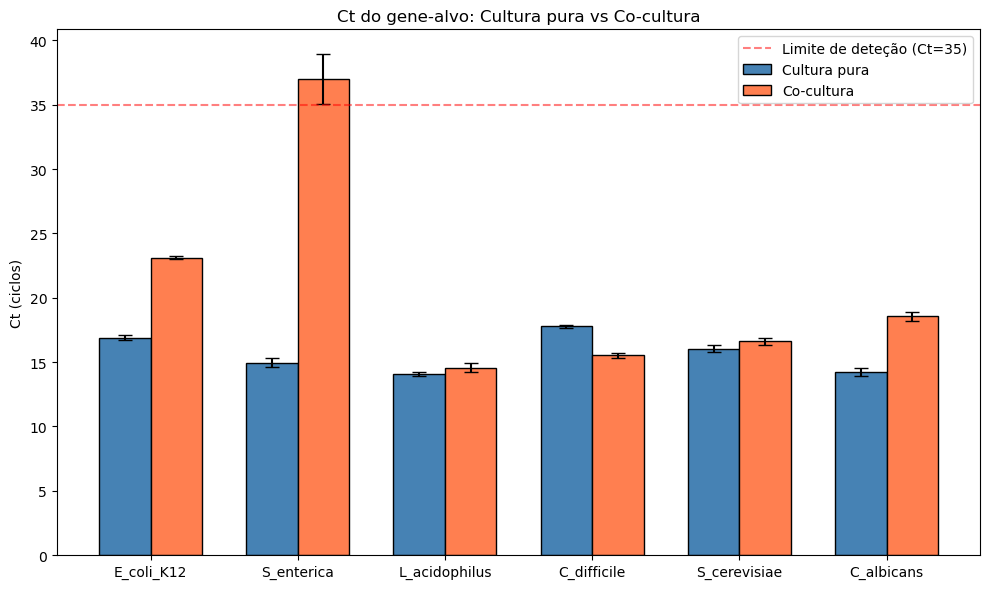

In [13]:
# Gráfico: Ct pura vs co-cultura lado a lado
fig, ax = plt.subplots(figsize=(10, 6))

primers = df_coculture['Primer'].unique()
x = np.arange(len(primers))
width = 0.35

# Separar dados
pura = ct_stats.loc[ct_stats['Condicao'] == 'Cultura_pura']
co = ct_stats.loc[ct_stats['Condicao'] == 'Co-cultura']

ax.bar(x - width/2, pura['Ct_mean'].values, width, yerr=pura['Ct_std'].values,
       capsize=5, label='Cultura pura', color='steelblue', edgecolor='black')
ax.bar(x + width/2, co['Ct_mean'].values, width, yerr=co['Ct_std'].values,
       capsize=5, label='Co-cultura', color='coral', edgecolor='black')

# Linha de corte para "não detetado"
ax.axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Limite de deteção (Ct=35)')

ax.set_xticks(x)
ax.set_xticklabels(primers)
ax.set_ylabel('Ct (ciclos)')
ax.set_title('Ct do gene-alvo: Cultura pura vs Co-cultura')
ax.legend()

plt.tight_layout()
plt.show()


## 3. Calcular ΔCt

**ΔCt = Ct_gene − Ct_ref**

O Ct_ref (16S/18S rRNA) mede a quantidade total de DNA na amostra.
Subtrair o Ct_ref normaliza as diferenças na quantidade de DNA extraído.

- ΔCt **baixo** → espécie abundante relativamente ao DNA total
- ΔCt **alto** → espécie pouco abundante

In [14]:
# Calcular ΔCt para cada medição
df_coculture['delta_ct'] = df_coculture['Ct_gene'] - df_coculture['Ct_ref']

print("ΔCt = Ct_gene − Ct_ref\n")
df_coculture[['Condicao', 'Primer', 'Replicate', 'Ct_gene', 'Ct_ref', 'delta_ct']].round(2)


ΔCt = Ct_gene − Ct_ref



,Condicao,Primer,Replicate,Ct_gene,Ct_ref,delta_ct
0,Cultura_pura,E_coli_K12,1,14.15,10.48,3.67
1,Cultura_pura,E_coli_K12,2,14.19,10.73,3.46
2,Cultura_pura,E_coli_K12,3,13.93,10.46,3.47
3,Co-cultura,E_coli_K12,1,14.97,10.62,4.35
4,Co-cultura,E_coli_K12,2,14.36,10.58,3.78
5,Co-cultura,E_coli_K12,3,14.36,10.43,3.93
6,Cultura_pura,S_enterica,1,14.57,10.21,4.36
7,Cultura_pura,S_enterica,2,13.98,10.42,3.56
8,Cultura_pura,S_enterica,3,14.20,10.55,3.65
9,Co-cultura,S_enterica,1,18.23,10.29,7.94


## 4. Calcular ΔΔCt

**ΔΔCt = ΔCt(co-cultura) − ΔCt(cultura pura)**

Compara cada espécie na co-cultura com a sua cultura pura (controlo).

- ΔΔCt **= 0** → mesma abundância nas duas condições
- ΔΔCt **> 0** → menos abundante na co-cultura (Ct subiu)
- ΔΔCt **< 0** → mais abundante na co-cultura (Ct desceu)


In [15]:
# Passo 1: Calcular ΔCt médio da cultura pura (controlo) para cada espécie
delta_ct_pura = df_coculture.loc[df_coculture['Condicao'] == 'Cultura_pura'].groupby('Primer')['delta_ct'].mean()

print("ΔCt médio da cultura pura (controlo):\n")
print(delta_ct_pura.round(2))


ΔCt médio da cultura pura (controlo):

Primer
C_albicans       6.35
C_difficile      4.54
E_coli_K12       3.53
L_acidophilus    7.26
S_cerevisiae     5.50
S_enterica       3.86
Name: delta_ct, dtype: float64


In [16]:
# Passo 2: Calcular ΔΔCt para cada medição da co-cultura
# ΔΔCt = ΔCt(co-cultura) − ΔCt médio(cultura pura)

df_co = df_coculture.loc[df_coculture['Condicao'] == 'Co-cultura'].copy()

# Para cada linha, subtrair o ΔCt médio da cultura pura da mesma espécie
df_co['delta_ct_pura'] = df_co['Primer'].map(delta_ct_pura)
df_co['delta_delta_ct'] = df_co['delta_ct'] - df_co['delta_ct_pura']

print("ΔΔCt = ΔCt(co-cultura) − ΔCt(cultura pura)\n")
df_co[['Primer', 'Replicate', 'delta_ct', 'delta_ct_pura', 'delta_delta_ct']].round(2)


ΔΔCt = ΔCt(co-cultura) − ΔCt(cultura pura)



,Primer,Replicate,delta_ct,delta_ct_pura,delta_delta_ct
3,E_coli_K12,1,4.35,3.53,0.82
4,E_coli_K12,2,3.78,3.53,0.25
5,E_coli_K12,3,3.93,3.53,0.40
9,S_enterica,1,7.94,3.86,4.08
10,S_enterica,2,8.47,3.86,4.61
11,S_enterica,3,8.23,3.86,4.37
15,L_acidophilus,1,4.54,7.26,-2.72
16,L_acidophilus,2,5.16,7.26,-2.10
17,L_acidophilus,3,5.43,7.26,-1.83
21,C_difficile,1,25.09,4.54,20.55


## 5. Calcular Fold Change

**FC = 2^(−ΔΔCt)**

O fold change indica quanto a abundância mudou na co-cultura em relação à cultura pura.

- FC **= 1** → sem alteração
- FC **> 1** → espécie mais abundante na co-cultura
- FC **< 1** → espécie menos abundante na co-cultura
- FC **≈ 0** → espécie eliminada/não detetada

In [17]:
# Calcular Fold Change
df_co['fold_change'] = 2 ** (-df_co['delta_delta_ct'])

print("Fold Change = 2^(−ΔΔCt)\n")
df_co[['Primer', 'Replicate', 'delta_delta_ct', 'fold_change']].round(3)


Fold Change = 2^(−ΔΔCt)



,Primer,Replicate,delta_delta_ct,fold_change
3,E_coli_K12,1,0.817,0.568
4,E_coli_K12,2,0.247,0.843
5,E_coli_K12,3,0.397,0.760
9,S_enterica,1,4.083,0.059
10,S_enterica,2,4.613,0.041
11,S_enterica,3,4.373,0.048
15,L_acidophilus,1,-2.717,6.574
16,L_acidophilus,2,-2.097,4.277
17,L_acidophilus,3,-1.827,3.547
21,C_difficile,1,20.553,0.000


In [18]:
# Resumo: média e SD do fold change por espécie
fc_stats = df_co.groupby('Primer')['fold_change'].agg(['mean', 'std']).round(3)
fc_stats.columns = ['FC_mean', 'FC_std']
fc_stats = fc_stats.sort_values('FC_mean', ascending=False)

print("Fold Change por espécie (co-cultura vs cultura pura):\n")
print(fc_stats)


Fold Change por espécie (co-cultura vs cultura pura):

               FC_mean  FC_std
Primer                        
L_acidophilus    4.799   1.579
E_coli_K12       0.723   0.141
S_cerevisiae     0.610   0.070
S_enterica       0.049   0.009
C_albicans       0.016   0.002
C_difficile      0.000   0.000


/tmp/ipykernel_1381861/213789568.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(especies, rotation=45, ha='right')


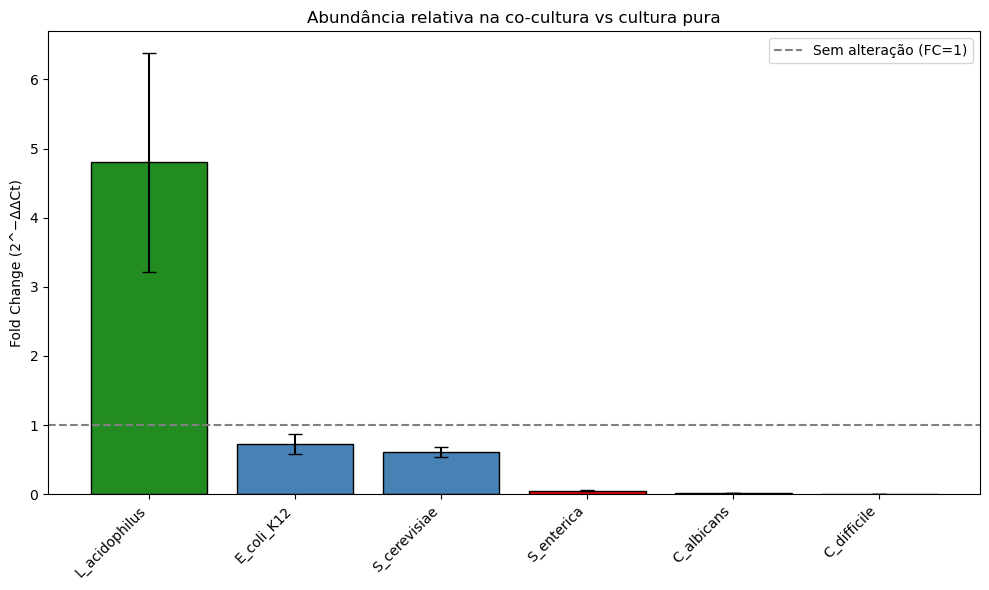

Verde  = espécie AUMENTOU na co-cultura
Azul   = sem grande alteração
Salmon = espécie REDUZIU na co-cultura
Red    = espécie ELIMINADA / não detetada


In [19]:
# Gráfico do Fold Change
fig, ax = plt.subplots(figsize=(10, 6))

especies = fc_stats.index.tolist()
means = fc_stats['FC_mean'].values
stds = fc_stats['FC_std'].values

colors = []
for m in means:
    if m > 1.5:
        colors.append('forestgreen')   # aumentou
    elif m < 0.1:
        colors.append('red')           # eliminado
    elif m < 0.5:
        colors.append('salmon')        # reduzido
    else:
        colors.append('steelblue')     # sem grande alteração

ax.bar(especies, means, yerr=stds, capsize=5, color=colors, edgecolor='black')
ax.axhline(y=1, color='gray', linestyle='--', label='Sem alteração (FC=1)')
ax.set_ylabel('Fold Change (2^−ΔΔCt)')
ax.set_title('Abundância relativa na co-cultura vs cultura pura')
ax.set_xticklabels(especies, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("Verde  = espécie AUMENTOU na co-cultura")
print("Azul   = sem grande alteração")
print("Salmon = espécie REDUZIU na co-cultura")
print("Red    = espécie ELIMINADA / não detetada")


## 6. Teste t — Cultura pura vs Co-cultura

Para cada espécie, comparar o ΔCt entre as duas condições.

- H₀: ΔCt(pura) = ΔCt(co-cultura) → não houve alteração
- Se p < 0.05 → a diferença é significativa


In [20]:
# t-test para cada espécie: cultura pura vs co-cultura
resultados_ttest = []

for primer in df_coculture['Primer'].unique():
    
    dct_pura = df_coculture.loc[(df_coculture['Primer'] == primer) & (df_coculture['Condicao'] == 'Cultura_pura'), 'delta_ct'].values
    dct_co   = df_coculture.loc[(df_coculture['Primer'] == primer) & (df_coculture['Condicao'] == 'Co-cultura'), 'delta_ct'].values
    
    t_stat, p_value = stats.ttest_ind(dct_pura, dct_co)
    
    fc_mean = df_co.loc[df_co['Primer'] == primer, 'fold_change'].mean()
    
    resultados_ttest.append({
        'Especie': primer,
        'ΔCt_pura': round(dct_pura.mean(), 2),
        'ΔCt_co': round(dct_co.mean(), 2),
        'FC': round(fc_mean, 3),
        't_stat': round(t_stat, 3),
        'p_value': round(p_value, 6),
        'Significativo': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    })

df_ttest = pd.DataFrame(resultados_ttest)

print("t-test: Cultura pura vs Co-cultura (por espécie)\n")
print(df_ttest.to_string(index=False))

print("\n*** p<0.001  |  ** p<0.01  |  * p<0.05  |  ns = não significativo")


t-test: Cultura pura vs Co-cultura (por espécie)

      Especie  ΔCt_pura  ΔCt_co    FC  t_stat  p_value Significativo
   E_coli_K12      3.53    4.02 0.723  -2.648 0.057102            ns
   S_enterica      3.86    8.21 0.049 -14.729 0.000124           ***
L_acidophilus      7.26    5.04 4.799   8.003 0.001322            **
  C_difficile      4.54   26.68 0.000 -19.332 0.000042           ***
 S_cerevisiae      5.50    6.22 0.610  -6.092 0.003671            **
   C_albicans      6.35   12.31 0.016 -25.130 0.000015           ***

*** p<0.001  |  ** p<0.01  |  * p<0.05  |  ns = não significativo


## 7. ANOVA One-way

Compara o fold change entre **todas as espécies** simultaneamente.

Pergunta: "As espécies respondem de forma diferente à co-cultura?"

- H₀: todas as espécies têm o mesmo fold change
- Se p < 0.05 → pelo menos uma espécie responde de forma diferente


In [21]:
# Separar fold change por espécie
grupos = []
nomes = []

for primer in df_co['Primer'].unique():
    fc_valores = df_co.loc[df_co['Primer'] == primer, 'fold_change'].values
    grupos.append(fc_valores)
    nomes.append(primer)

# ANOVA One-way
f_stat, p_value = stats.f_oneway(*grupos)

print("ANOVA One-way (Fold Change entre espécies):")
print(f"  F = {f_stat:.4f}")
print(f"  p = {p_value:.8f}")

if p_value < 0.05:
    print("\n→ p < 0.05: As espécies respondem de forma DIFERENTE à co-cultura!")
else:
    print("\n→ p ≥ 0.05: Sem diferenças significativas entre espécies")


ANOVA One-way (Fold Change entre espécies):
  F = 25.0498
  p = 0.00000583

→ p < 0.05: As espécies respondem de forma DIFERENTE à co-cultura!
